# **libraries**

In [8]:
import pandas as pd

In [14]:
import numpy as np

In [27]:
from sklearn.preprocessing import StandardScaler

In [40]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [45]:
from sklearn.model_selection import train_test_split

In [76]:
import seaborn as sns

In [50]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import tensorflow as tf
from tensorflow import keras


In [58]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical

In [60]:
from tensorflow.keras.callbacks import EarlyStopping

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

# **dataset import**

In [9]:
link = 'https://drive.google.com/file/d/122o_9LUE9T97wNnBVLSo7omp7-XWEnxl/view'
id = link.split('/')[-2]
path = f"https://drive.google.com/uc?id={id}"
df = pd.read_csv(path)

In [ ]:
df.head(50)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03
5,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03
6,Resort Hotel,0,0,2015,July,27,1,0,2,2,...,No Deposit,NaN,NaN,0,Transient,107.00,0,0,Check-Out,2015-07-03
7,Resort Hotel,0,9,2015,July,27,1,0,2,2,...,No Deposit,303.0,NaN,0,Transient,103.00,0,1,Check-Out,2015-07-03
8,Resort Hotel,1,85,2015,July,27,1,0,3,2,...,No Deposit,240.0,NaN,0,Transient,82.00,0,1,Canceled,2015-05-06
9,Resort Hotel,1,75,2015,July,27,1,0,3,2,...,No Deposit,15.0,NaN,0,Transient,105.50,0,0,Canceled,2015-04-22


In [75]:
df.shape

(119390, 18)

# **feature selection+managing values**

In [10]:
df = df.drop(columns=['agent','company','is_canceled','arrival_date_year','adults','children','babies','is_repeated_guest','previous_cancellations','previous_bookings_not_canceled','assigned_room_type','booking_changes','deposit_type','company','days_in_waiting_list','required_car_parking_spaces','reservation_status','reservation_status_date'])
df['total_stay_duration'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']

In [11]:
cluster_features = [
    'hotel',
    'lead_time',
    'meal',
    'country',
    'market_segment',
    'distribution_channel',
    'reserved_room_type',
    'customer_type',
    'adr',
    'total_of_special_requests',
    'total_stay_duration'
]
df_cluster = df[cluster_features].copy()
print(f"Shape of clustering data: {df_cluster.shape}")
print(df_cluster.head())

Shape of clustering data: (119390, 11)
          hotel  lead_time meal country market_segment distribution_channel  \
0  Resort Hotel        342   BB     PRT         Direct               Direct   
1  Resort Hotel        737   BB     PRT         Direct               Direct   
2  Resort Hotel          7   BB     GBR         Direct               Direct   
3  Resort Hotel         13   BB     GBR      Corporate            Corporate   
4  Resort Hotel         14   BB     GBR      Online TA                TA/TO   

  reserved_room_type customer_type   adr  total_of_special_requests  \
0                  C     Transient   0.0                          0   
1                  C     Transient   0.0                          0   
2                  A     Transient  75.0                          0   
3                  A     Transient  75.0                          0   
4                  A     Transient  98.0                          1   

   total_stay_duration  
0                    0  
1        

In [12]:
df_cluster.shape

(119390, 11)

In [13]:
df_cluster.head(10)

,hotel,lead_time,meal,country,market_segment,distribution_channel,reserved_room_type,customer_type,adr,total_of_special_requests,total_stay_duration
0,Resort Hotel,342,BB,PRT,Direct,Direct,C,Transient,0.0,0,0
1,Resort Hotel,737,BB,PRT,Direct,Direct,C,Transient,0.0,0,0
2,Resort Hotel,7,BB,GBR,Direct,Direct,A,Transient,75.0,0,1
3,Resort Hotel,13,BB,GBR,Corporate,Corporate,A,Transient,75.0,0,1
4,Resort Hotel,14,BB,GBR,Online TA,TA/TO,A,Transient,98.0,1,2
5,Resort Hotel,14,BB,GBR,Online TA,TA/TO,A,Transient,98.0,1,2
6,Resort Hotel,0,BB,PRT,Direct,Direct,C,Transient,107.0,0,2
7,Resort Hotel,9,FB,PRT,Direct,Direct,C,Transient,103.0,1,2
8,Resort Hotel,85,BB,PRT,Online TA,TA/TO,A,Transient,82.0,1,3
9,Resort Hotel,75,HB,PRT,Offline TA/TO,TA/TO,D,Transient,105.5,0,3


In [15]:
for col in df_cluster.columns:
    unique_values = df[col].unique()
    print(unique_values)

['Resort Hotel' 'City Hotel']
[342 737   7  13  14   0   9  85  75  23  35  68  18  37  12  72 127  78
  48  60  77  99 118  95  96  69  45  40  15  36  43  70  16 107  47 113
  90  50  93  76   3   1  10   5  17  51  71  63  62 101   2  81 368 364
 324  79  21 109 102   4  98  92  26  73 115  86  52  29  30  33  32   8
 100  44  80  97  64  39  34  27  82  94 110 111  84  66 104  28 258 112
  65  67  55  88  54 292  83 105 280 394  24 103 366 249  22  91  11 108
 106  31  87  41 304 117  59  53  58 116  42 321  38  56  49 317   6  57
  19  25 315 123  46  89  61 312 299 130  74 298 119  20 286 136 129 124
 327 131 460 140 114 139 122 137 126 120 128 135 150 143 151 132 125 157
 147 138 156 164 346 159 160 161 333 381 149 154 297 163 314 155 323 340
 356 142 328 144 336 248 302 175 344 382 146 170 166 338 167 310 148 165
 172 171 145 121 178 305 173 152 354 347 158 185 349 183 352 177 200 192
 361 207 174 330 134 350 334 283 153 197 133 241 193 235 194 261 260 216
 169 209 238 215 141 

In [24]:
df_cluster = df_cluster.replace('Undefined', np.nan)

In [25]:
def fill_null(column):

    missing = column.isnull()
    total_missing = missing.sum()

    if total_missing > 0:

        top_3_values = column.value_counts().nlargest(3).index.tolist()
        random_fillers = np.random.choice(top_3_values, size=total_missing)

        column.loc[missing] = random_fillers


    return column

for col in df_cluster.columns:
    df_cluster[col] = fill_null(df_cluster[col])


/tmp/ipython-input-3982726065.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  column.loc[missing] = random_fillers
/tmp/ipython-input-3982726065.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  column.loc[missing] = random_fillers
/tmp/ipython-input-3982726065.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  column.loc[missing] = random_fillers
/tmp/ipython-input-3982726065.py:11: SettingWithCopyWarning: 
A value is trying

In [26]:
string_cols = [
    'hotel',
    'meal',
    'country',
    'market_segment',
    'distribution_channel',
    'reserved_room_type',
    'customer_type'
]
#one hot encoding
df_cluster_encoded = pd.get_dummies(df_cluster, columns=string_cols, drop_first=True)

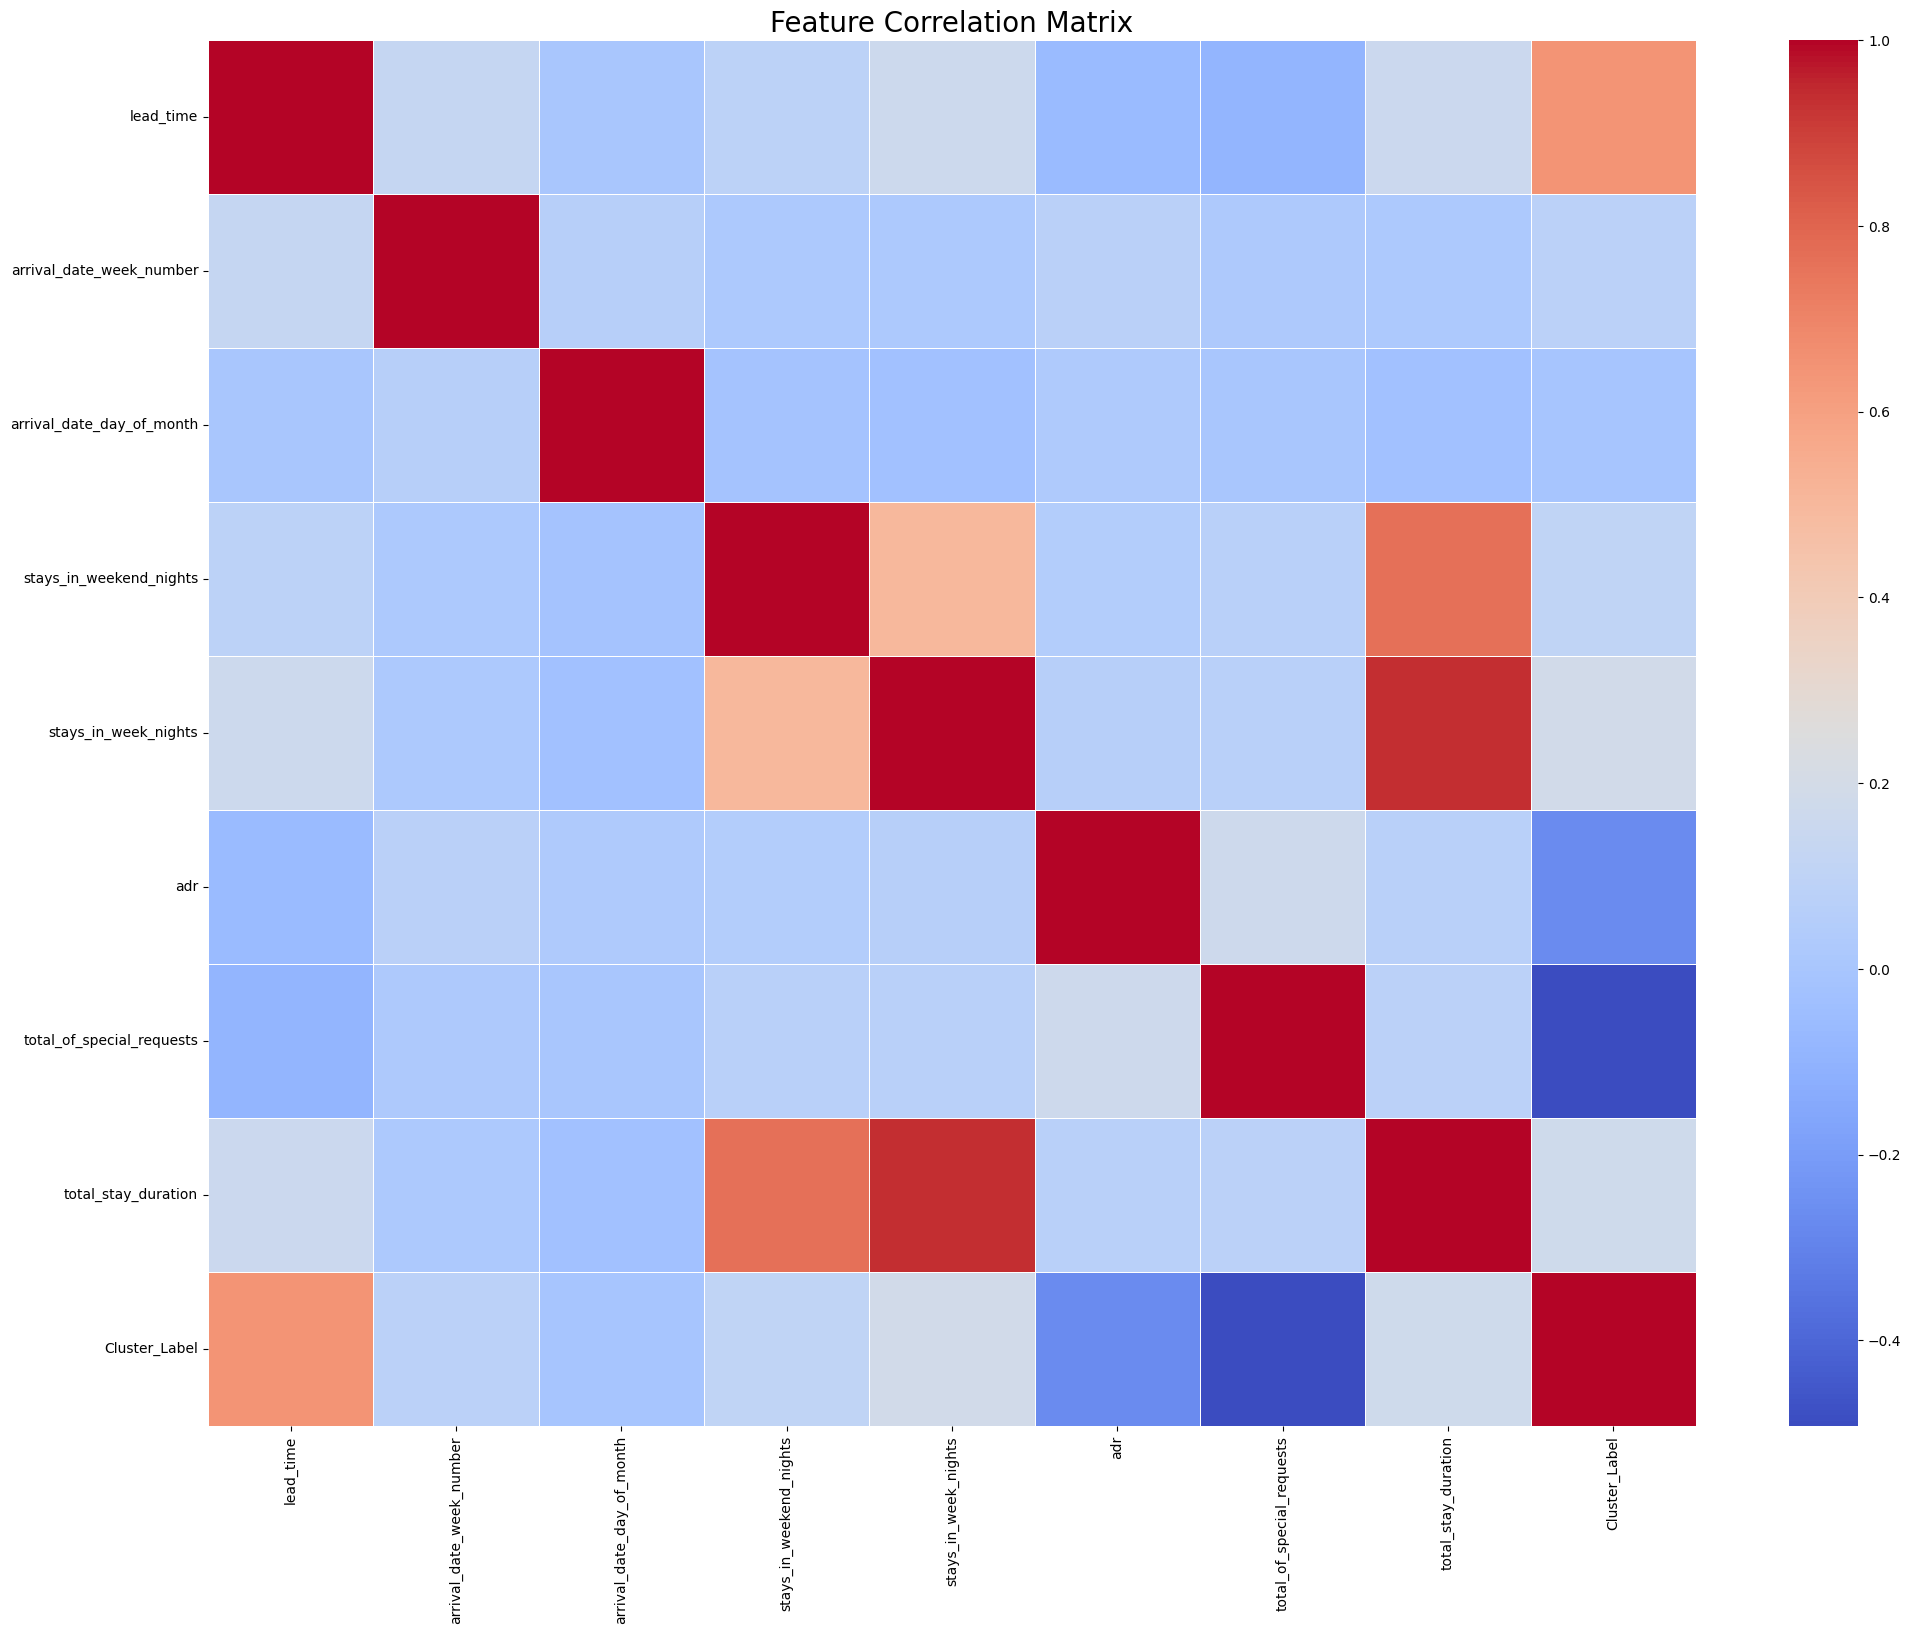

In [77]:
#Heatmap correlation

numeric_df = df.select_dtypes(include=[np.number])

corr_matrix = numeric_df.corr()


plt.figure(figsize=(24, 18))

sns.heatmap(corr_matrix, cmap='coolwarm', linewidths=0.5, annot=False)

plt.title('Feature Correlation Matrix', fontsize=20)
plt.show()

# **feature scaling**

In [34]:
df_cluster_encoded.head(5)

,lead_time,adr,total_of_special_requests,total_stay_duration,hotel_Resort Hotel,meal_FB,meal_HB,meal_SC,country_AGO,country_AIA,...,reserved_room_type_D,reserved_room_type_E,reserved_room_type_F,reserved_room_type_G,reserved_room_type_H,reserved_room_type_L,reserved_room_type_P,customer_type_Group,customer_type_Transient,customer_type_Transient-Party
0,342,0.0,0,0,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
1,737,0.0,0,0,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
2,7,75.0,0,1,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
3,13,75.0,0,1,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
4,14,98.0,1,2,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False


In [38]:
scaler = StandardScaler()
numerical_cols = ['lead_time', 'adr', 'total_of_special_requests', 'total_stay_duration']

df_numerical = df_cluster_encoded[numerical_cols]
df_categorical = df_cluster_encoded.drop(columns=numerical_cols)

df_numerical_scaled = pd.DataFrame(
    scaler.fit_transform(df_numerical),
    columns=numerical_cols,
    index=df_numerical.index #to match index
)

df_preprocessed = pd.concat([df_numerical_scaled, df_categorical], axis=1)

In [39]:
df_preprocessed.head(5)

,lead_time,adr,total_of_special_requests,total_stay_duration,hotel_Resort Hotel,meal_FB,meal_HB,meal_SC,country_AGO,country_AIA,...,reserved_room_type_D,reserved_room_type_E,reserved_room_type_F,reserved_room_type_G,reserved_room_type_H,reserved_room_type_L,reserved_room_type_P,customer_type_Group,customer_type_Transient,customer_type_Transient-Party
0,2.227051,-2.015038,-0.720694,-1.340370,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
1,5.923385,-2.015038,-0.720694,-1.340370,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
2,-0.907814,-0.530935,-0.720694,-0.949352,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
3,-0.851667,-0.530935,-0.720694,-0.949352,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
4,-0.842309,-0.075810,0.540666,-0.558334,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False


# **KMeans**

In [41]:
k_range = range(1,11)
inertia_values = []

for k in k_range:

    kmeans = KMeans(n_clusters= k, random_state=42, n_init = 10)
    kmeans.fit(df_preprocessed)
    inertia_values.append(kmeans.inertia_)

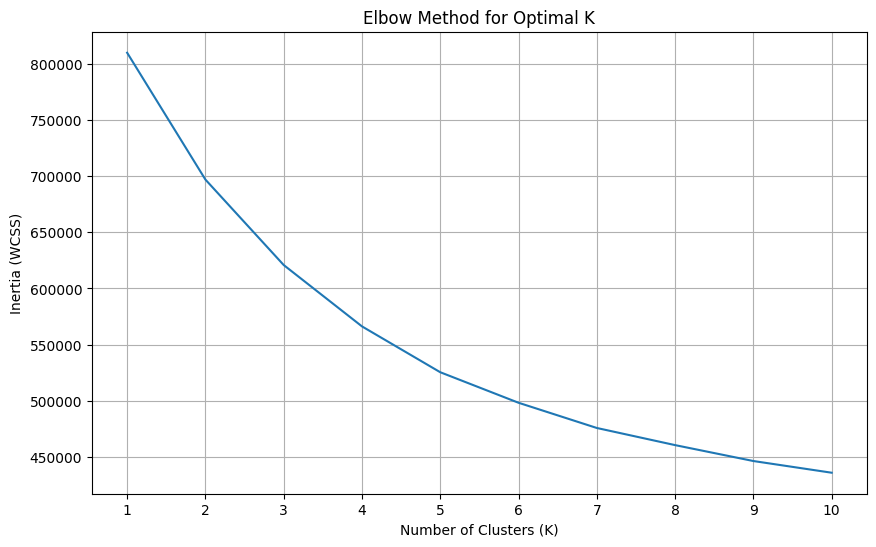

In [43]:
plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia_values)
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (WCSS)')
plt.xticks(k_range)
plt.grid(True)
plt.show()
#lets say k = 4, as no visible elbow point

In [44]:
optimal_k = 4

kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans_final.fit(df_preprocessed)

cluster_labels = kmeans_final.labels_
df['Cluster_Label'] = cluster_labels

print(df['Cluster_Label'].value_counts().sort_index())

print("\nAverage Price (ADR) per Cluster:")
print(df.groupby('Cluster_Label')['adr'].mean())

Cluster_Label
0    35159
1    50383
2    14002
3    19846
Name: count, dtype: int64

Average Price (ADR) per Cluster:
Cluster_Label
0    131.497849
1     87.084234
2    102.071251
3     86.542280
Name: adr, dtype: float64


# **Models,training**

In [46]:
def get_season(month):
    if month in ['November', 'December', 'January', 'February']:
        return 'Winter'
    elif month in ['March', 'April', 'May']:
        return 'Spring'
    elif month in ['June', 'July', 'August']:
        return 'Summer'
    else:
        return 'Autumn'

In [47]:
#adding seasons based on our month
df['season'] = df['arrival_date_month'].apply(get_season)

In [49]:
X_raw = df[['arrival_date_month', 'arrival_date_day_of_month', 'season']]
y = df['Cluster_Label']

# One Hot Encoding for months and seasons
X = pd.get_dummies(X_raw, columns=['arrival_date_month', 'season'], drop_first=False)

# date encoding in between 0 to 1 for NN
X['arrival_date_day_of_month'] = X['arrival_date_day_of_month'] / 31.0



In [51]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [52]:
#Random Forest
rf_model = RandomForestClassifier(n_estimators= 100, random_state = 42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [55]:
rf_pred = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_pred)
print(f"Random Forest Accuracy: {rf_accuracy:.4f}")

Random Forest Accuracy: 0.4727


In [56]:
#KNN
knn_model = KNeighborsClassifier(n_neighbors = 5)
knn_model.fit(X_train, y_train)

KNeighborsClassifier()

In [57]:
knn_pred = knn_model.predict(X_test)
knn_acc = accuracy_score(y_test,knn_pred)
print(f"KNN Accuracy: {knn_acc:.4f}")

KNN Accuracy: 0.4247


In [59]:
#NN
labels = 4 #4 clusters/classes
#one hot encoding keras version
y_train_cat = keras.utils.to_categorical(y_train, labels)
y_test_cat = keras.utils.to_categorical(y_test, labels)


nn_model = Sequential([
    #input x_test.shape,first layer 64 neurons
    Dense(64,activation='relu',input_shape = (X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(labels,activation = 'softmax')
])

nn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [63]:
es = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)
history = nn_model.fit(
    X_train, y_train_cat,
    validation_data=(X_test, y_test_cat),
    epochs=20,
    batch_size=64,
    #callbacks = [es],
    verbose=1,
    validation_split = 0.2
)
#with es, accuracy 4.573
#without es, 0.4585
#although can tune the parameters with GridSearchCV and kt.randomsearch

Epoch 1/20
1493/1493 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.4531 - loss: 1.2118 - val_accuracy: 0.4554 - val_loss: 1.2118
Epoch 2/20
1493/1493 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.4551 - loss: 1.2089 - val_accuracy: 0.4552 - val_loss: 1.2103
Epoch 3/20
1493/1493 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4533 - loss: 1.2109 - val_accuracy: 0.4516 - val_loss: 1.2100
Epoch 4/20
1493/1493 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.4575 - loss: 1.2054 - val_accuracy: 0.4551 - val_loss: 1.2084
Epoch 5/20
1493/1493 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.4583 - loss: 1.2059 - val_accuracy: 0.4556 - val_loss: 1.2081
Epoch 6/20
1493/1493 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4564 - loss: 1.2066 - val_accuracy: 0.4549 - val_loss: 1.2083
Epoch 7/20
1493/1493 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4562 - loss: 1.2082 - val_accuracy: 0.4560 - val_loss: 1.2083
Epoch 8/20
1493/1493 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.4543 - loss: 1.2092 - 

In [69]:
nn_probs = nn_model.predict(X_test)
nn_pred = np.argmax(nn_probs, axis=1)

747/747 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


In [72]:
nn_predicted_labels = np.argmax(nn_probs, axis=1)

# **Comparison and Visualization**

Random Forest Report
              precision    recall  f1-score   support

           0       0.39      0.37      0.38      6868
           1       0.53      0.75      0.62     10163
           2       0.32      0.00      0.01      2848
           3       0.39      0.28      0.33      3999

    accuracy                           0.47     23878
   macro avg       0.41      0.35      0.33     23878
weighted avg       0.44      0.47      0.43     23878

KNN Report
              precision    recall  f1-score   support

           0       0.35      0.38      0.36      6868
           1       0.50      0.64      0.56     10163
           2       0.17      0.03      0.05      2848
           3       0.32      0.23      0.27      3999

    accuracy                           0.42     23878
   macro avg       0.34      0.32      0.31     23878
weighted avg       0.39      0.42      0.40     23878

Neural Network Report
              precision    recall  f1-score   support

           0       0.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


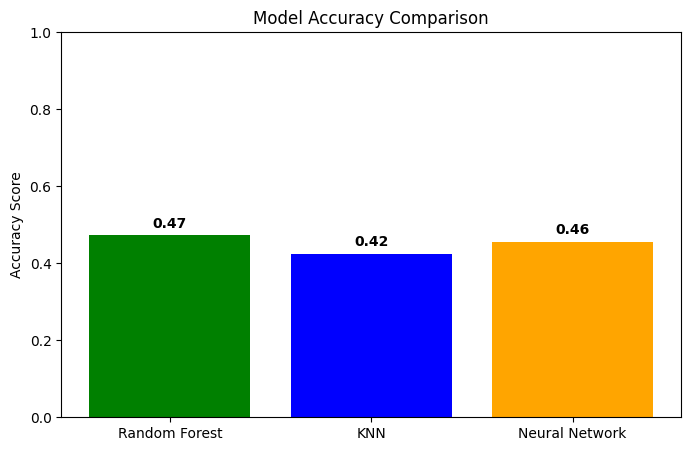

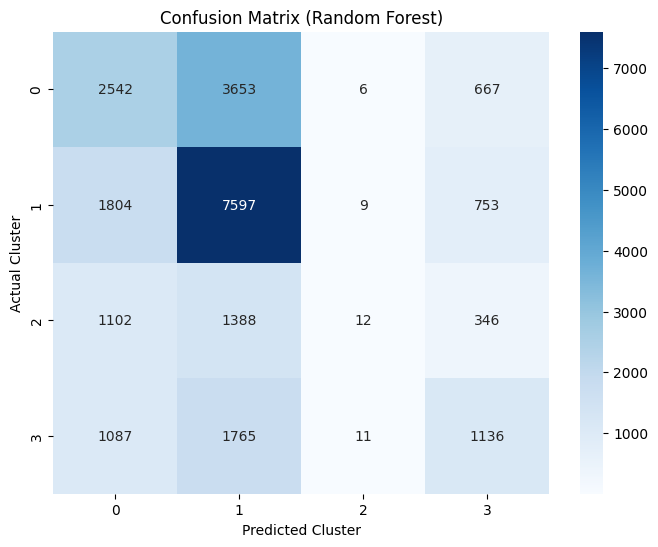

In [73]:
print("Random Forest Report")
print(classification_report(y_test, rf_pred))

print("KNN Report")
print(classification_report(y_test, knn_pred))

print("Neural Network Report")
print(classification_report(y_test, nn_predicted_labels))

models = ['Random Forest', 'KNN', 'Neural Network']

nn_acc = accuracy_score(y_test, nn_predicted_labels)
accuracies = [rf_accuracy, knn_acc, nn_acc]

plt.figure(figsize=(8, 5))
plt.bar(models, accuracies, color=['green', 'blue', 'orange'])
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy Score')
plt.ylim(0, 1.0) # Set y-axis from 0 to 100%
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center', fontweight='bold')
plt.show()

#rf because,it has the best answer
cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (Random Forest)')
plt.xlabel('Predicted Cluster')
plt.ylabel('Actual Cluster')
plt.show()